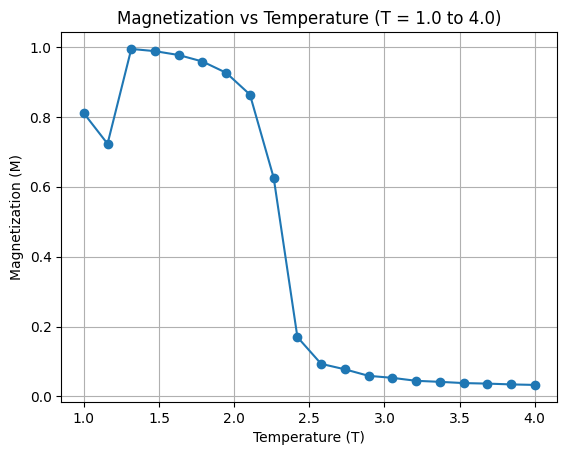

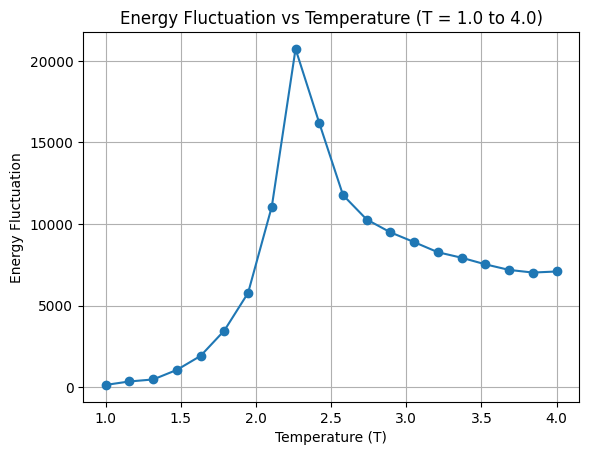

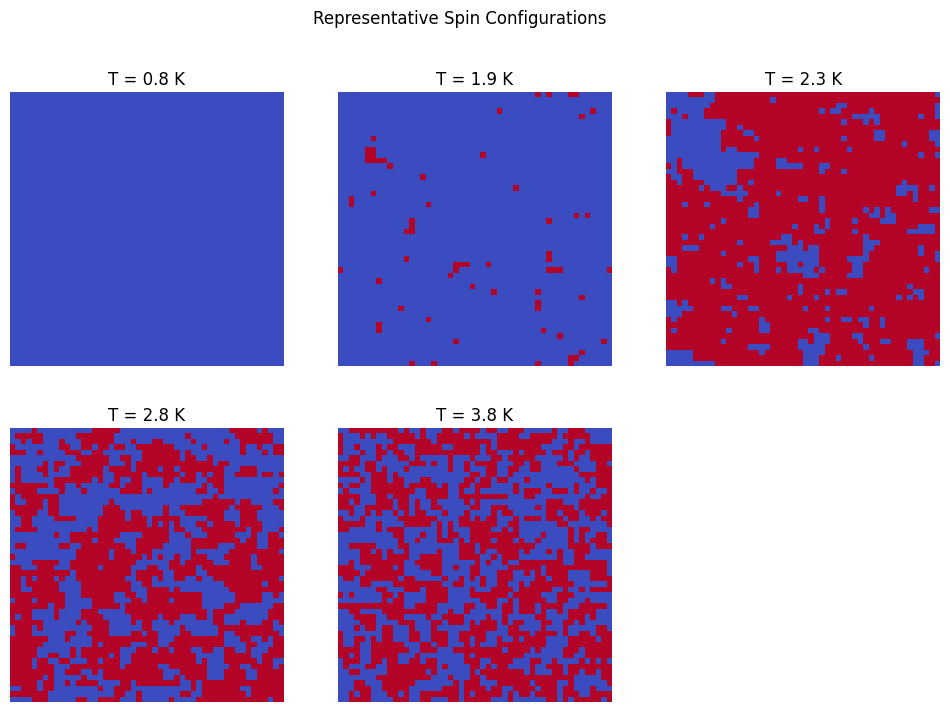

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from multiprocessing import Pool

#Set seed
np.random.seed(1)

def initialize_spins(Lx, Ly):
    '''Create a 2d array of spin'''
    return np.random.choice([1, -1], size=(Lx, Ly))

def calculate_energy(spins, J):
    '''Calculation of Energy of the 2d lattice using periodic boundary condition'''
    kernel = np.array([
        [0, 1, 0],
        [1, 0, 1],
        [0, 1, 0]
    ])
    return -J * np.sum(spins * convolve2d(spins, kernel, mode="same", boundary="wrap")) / 2

def metropolis_step(spins, B, J):
    '''Perform single metropolis update on 2d lattice at random location'''
    Lx, Ly = spins.shape

    for _ in range(Lx * Ly):
        i = np.random.randint(Lx)
        j = np.random.randint(Ly)

        delta_E = 2 * J * spins[i, j] * (
            spins[(i-1)%Lx, j] + spins[(i+1)%Lx, j] +
            spins[i, (j+1)%Ly] + spins[i, (j-1)%Ly]
        )

        if delta_E <= 0 or np.random.rand() < np.exp(-B * delta_E):
            spins[i, j] *= -1

    return spins

def simulate_ising_2d(Lx, Ly, J, T, n_steps):
    """Run the 2D Ising model simulation."""
    B = 1.0 / T
    spins = initialize_spins(Lx, Ly)
    magnetizations = []
    energies = []

    for step in range(n_steps):
        spins = metropolis_step(spins, B, J)
        magnetizations.append(np.mean(spins))
        energies.append(calculate_energy(spins, J))

    return spins, magnetizations, energies


#Global parameters
J = 1.0
Lx, Ly = 50, 50
T_values = np.linspace(1, 4, 20)

equil_steps = 2000
measure_steps = 3000


#Parallel function for magnetization
def simulate_for_T(T):
    results = []

    for _ in range(3):
        np.random.seed()

        spins = initialize_spins(Lx, Ly)
        B = 1.0 / T
        mags = []

        for _ in range(equil_steps):
            spins = metropolis_step(spins, B, J)

        for _ in range(measure_steps):
            spins = metropolis_step(spins, B, J)
            mags.append(np.mean(spins))

        results.append(np.mean(np.abs(mags)))

    return np.mean(results)


#Parallel function for energy fluctuation
def energy_for_T(T):
    results = []

    for _ in range(3):
        np.random.seed()

        spins = initialize_spins(Lx, Ly)
        B = 1.0 / T
        energies = []

        for _ in range(equil_steps):
            spins = metropolis_step(spins, B, J)

        for _ in range(measure_steps):
            spins = metropolis_step(spins, B, J)
            energies.append(calculate_energy(spins, J))

        results.append(np.var(energies))

    return np.mean(results)


#Representative spin states for the 5 different Temprature Values
def plot_representative_states():
    T_vals = [0.8, 1.9, 2.3, 2.8, 3.8]

    plt.figure(figsize=(12, 8))

    for i, T in enumerate(T_vals):
        spins, _, _ = simulate_ising_2d(Lx, Ly, J, T, 5000)

        plt.subplot(2, 3, i+1)
        plt.imshow(spins, cmap='coolwarm')
        plt.title(f"T = {T} K")
        plt.axis('off')

    plt.suptitle("Representative Spin Configurations")
    plt.show()


#Final execution
if __name__ == "__main__":

    #Parallel Magnetization
    with Pool() as pool:
        M_values = pool.map(simulate_for_T, T_values)

    plt.figure()
    plt.plot(T_values, M_values, 'o-')
    plt.xlabel("Temperature (T)")
    plt.ylabel("Magnetization (M)")
    plt.title(f"Magnetization vs Temperature (T = {T_values[0]:.1f} to {T_values[-1]:.1f})")
    plt.grid()
    plt.show()

    #Parallel Energy Fluctuation
    with Pool() as pool:
        F_values = pool.map(energy_for_T, T_values)

    plt.figure()
    plt.plot(T_values, F_values, 'o-')
    plt.xlabel("Temperature (T)")
    plt.ylabel("Energy Fluctuation")
    plt.title(f"Energy Fluctuation vs Temperature (T = {T_values[0]:.1f} to {T_values[-1]:.1f})")
    plt.grid()
    plt.show()

    #Spin configurations
    plot_representative_states()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from multiprocessing import Pool

np.random.seed(1)

def initialize_spins(Lx, Ly):
    return np.random.choice([1, -1], size=(Lx, Ly))

def calculate_energy(spins, J):
    kernel = np.array([
        [0, 1, 0],
        [1, 0, 1],
        [0, 1, 0]
    ])
    return -J * np.sum(spins * convolve2d(spins, kernel, mode="same", boundary="wrap")) / 2

def metropolis_step(spins, B, J):
    Lx, Ly = spins.shape

    for _ in range(Lx * Ly):
        i = np.random.randint(Lx)
        j = np.random.randint(Ly)

        delta_E = 2 * J * spins[i, j] * (
            spins[(i-1)%Lx, j] + spins[(i+1)%Lx, j] +
            spins[i, (j+1)%Ly] + spins[i, (j-1)%Ly]
        )

        if delta_E <= 0 or np.random.rand() < np.exp(-B * delta_E):
            spins[i, j] *= -1

    return spins

def simulate_ising_2d(Lx, Ly, J, T, n_steps):
    B = 1.0 / T
    spins = initialize_spins(Lx, Ly)
    magnetizations = []
    energies = []

    for step in range(n_steps):
        spins = metropolis_step(spins, B, J)
        magnetizations.append(np.abs(np.mean(spins)))
        energies.append(calculate_energy(spins, J))

    return spins, magnetizations, energies


J = 1.0
Lx, Ly = 50, 50
T_values = np.linspace(1, 4, 20)

equil_steps = 2000
measure_steps = 3000


def simulate_for_T(T):
    results = []

    for _ in range(3):
        np.random.seed()

        spins = initialize_spins(Lx, Ly)
        B = 1.0 / T
        mags = []

        for _ in range(equil_steps):
            spins = metropolis_step(spins, B, J)

        for _ in range(measure_steps):
            spins = metropolis_step(spins, B, J)
            mags.append(np.abs(np.mean(spins)))

        results.append(np.mean(mags))

    return np.mean(results)


def energy_for_T(T):
    results = []

    for _ in range(3):
        np.random.seed()

        spins = initialize_spins(Lx, Ly)
        B = 1.0 / T
        energies = []

        for _ in range(equil_steps):
            spins = metropolis_step(spins, B, J)

        for _ in range(measure_steps):
            spins = metropolis_step(spins, B, J)
            energies.append(calculate_energy(spins, J))

        E = np.array(energies)
        results.append((np.mean(E**2) - np.mean(E)**2) / (T**2 * Lx * Ly))

    return np.mean(results)


def plot_representative_states():
    T_vals = [0.8, 1.9, 2.3, 2.8, 3.8]

    plt.figure(figsize=(12, 8))

    for i, T in enumerate(T_vals):
        spins, _, _ = simulate_ising_2d(Lx, Ly, J, T, 5000)

        plt.subplot(2, 3, i+1)
        plt.imshow(spins, cmap='coolwarm')
        plt.title(f"T = {T} K")
        plt.axis('off')

    plt.suptitle("Representative Spin Configurations")
    plt.show()


if __name__ == "__main__":

    with Pool() as pool:
        M_values = pool.map(simulate_for_T, T_values)

    plt.figure()
    plt.plot(T_values, M_values, 'o-')
    plt.xlabel("Temperature (T)")
    plt.ylabel("Magnetization (M)")
    plt.title(f"Magnetization vs Temperature (T = {T_values[0]:.1f} to {T_values[-1]:.1f})")
    plt.grid()
    plt.show()

    with Pool() as pool:
        F_values = pool.map(energy_for_T, T_values)

    plt.figure()
    plt.plot(T_values, F_values, 'o-')
    plt.xlabel("Temperature (T)")
    plt.ylabel("Energy Fluctuation")
    plt.title(f"Energy Fluctuation vs Temperature (T = {T_values[0]:.1f} to {T_values[-1]:.1f})")
    plt.grid()
    plt.show()

    plot_representative_states()